In [6]:
import torch, torchaudio
def cutout(spec, seq_len, cutout_val=' -r $REPEAT', num_rectangles=5, max_width=100, max_height=10):
    '''
    cutout_val: 'mean', 'mean_recording', 'zero'
    assumes a batch size of 1 (rearange to (F, B*N) if batch size > 1)
    '''
    if num_rectangles == 0: return spec

    spec_n = spec.shape[-1]
    ratio = spec_n / seq_len
    num_rectangles = int(num_rectangles * ratio) # if this spectrogram is shorter than the sequence lentgth used for tuning reduce the number of rectangles

    widths = torch.randint(1, max_width, (num_rectangles,))
    heights = torch.randint(1, max_height, (num_rectangles,))
    start_positions_x = torch.randint(0, spec.shape[-1], (num_rectangles,))
    end_positions_x = (start_positions_x + widths).clamp(max=spec.shape[-1])
    start_positions_y = torch.randint(0, spec.shape[-2], (num_rectangles,))
    end_positions_y = (start_positions_y + heights).clamp(max=spec.shape[-2])
    
    if cutout_val == 'mean_recording':
        mask_value = spec.mean()
    elif cutout_val == 'mean':
        mask_values = []
        for i in range(num_rectangles):
            mask_values.append(spec[:, start_positions_y[i]:end_positions_y[i], start_positions_x[i]:end_positions_x[i]].mean())

    for i in range(num_rectangles):
        #print(start_positions_x[i], end_positions_x[i], start_positions_y[i], end_positions_y[i])
        if cutout_val == 'mean':
            spec[:, start_positions_y[i]:end_positions_y[i], start_positions_x[i]:end_positions_x[i]] = mask_values[i]
        elif cutout_val == 'mean_recording':
            spec[:, start_positions_y[i]:end_positions_y[i], start_positions_x[i]:end_positions_x[i]] = mask_value
        elif cutout_val == 'zero':
            spec[:, start_positions_y[i]:end_positions_y[i], start_positions_x[i]:end_positions_x[i]].zero_()
    return spec

In [9]:
audio, sr = torchaudio.load("out.wav")
print(audio.shape, sr)

torch.Size([1, 208200]) 24000


In [57]:
WIN_LENGTH = 400
HOP_LENGTH = 160
SR =sr
import math
def to_spectogram(waveform:torch.Tensor, global_normalisation=True):
    '''some of config i,e win and n_fft is from: https://github.com/robflynnyh/NeMo/blob/main/nemo/collections/asr/parts/preprocessing/features.py
    '''
    spec = torchaudio.transforms.MelSpectrogram(
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = 2 ** math.ceil(math.log2(WIN_LENGTH)), # 512
        n_mels = 80,
        normalized = False
    )(waveform)
    # normalize
    if global_normalisation:
        spec = (spec - spec.mean(-1, keepdim=True)) / spec.std(-1, keepdim=True)
    return spec

torch.Size([80, 1002])


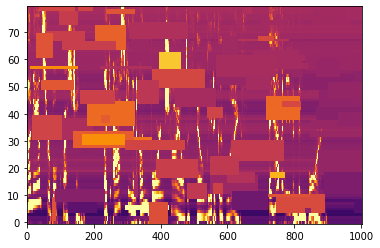

In [69]:
import matplotlib.pyplot as plt
spec_transform = to_spectogram
spec = spec_transform(audio[0])[:,300:1900]

print(spec.shape)
spec = cutout(spec.unsqueeze(0), seq_len=spec.shape[-1], cutout_val='mean', num_rectangles=100, max_width=200, max_height=10).squeeze(0)

plt.imshow(spec[:].numpy(), origin='lower', aspect='auto', cmap='inferno', interpolation='none', vmax=1, vmin=-1)
plt.savefig("spec_cutout.pdf", bbox_inches='tight')

In [16]:
spec.shape

torch.Size([80, 50772])

In [2]:
!ls

 566.mp3
 acp21rjf@cassini.dcs.shef.ac.uk
 ami_public_manual_1.6.2.zip
 anaconda3
 arxiv-latex-cleaner
 ary.pt
 a.txt
 a.txt.out
 audio_signal.npy
 audio_text_pairs_10_percent.json
 audio_text_pairs_90_percent.json
 augmentation.pdf
 base.pt
 Bessemer
 bitmap.png
 b.txt
 cassini
 cassini_rob
 cassini_rob.pub
 CITATION.cff
 create_and_run.py
 create_manifest_and_df_from_hf.py
 cross_attention_dynamic_pos.ipynb
 Database.kdbx
 DDR
 delib.tikz
 Desktop
 diarization.py
 direction_quadrents.pdf
 direction_quadrents.svg
 Documents
 dogcat
 Downloads
 dpos.py
 drawing-1.svg
 drawing.svg
 earnings22_n_seq_sched_360000_rp_1_test_recording_0_transcripts.pkl
 earnings22_n_seq_sched_360000_rp_1_test_recording_0_wers.pt
 earnings22_n_seq_sched_360000_rp_1_test_recording_1_transcripts.pkl
 earnings22_n_seq_sched_360000_rp_1_test_recording_1_wers.pt
 earnings22.tar.gz
 earnings22_test_recording_0.pt
 evals_rb_post_windowed_attn_per_rec.csv
 Ford
 GPUCache
 H-drive
 hel.s
 in-context-asr
 index.html
 